### Environment Setting

In [ ]:
! nvidia-smi

Thu Jan 30 18:13:37 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch

if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Using CPU")

Using GPU: Tesla T4


In [ ]:
#!pip install --upgrade accelerate
#!pip install --upgrade accelerate transformers torch
!pip install pytorch-lightning
!pip install transformers
!pip install farasapy
!pip install PyArabic
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.3/819.3 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 113.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 927.3/927.3 kB 55.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlin

### Configuration

In [ ]:
import pandas as pd
import json
import numpy as np


from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import Perceptron
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Random Forests
# Support Vector Machines
# XGboost
# Perceptron


## Load the Data

In [ ]:

#train_data='/content/All_ArMPro_binary_train.jsonl'
train_data='/content/All_ArMPro_binary_train_with_Subjectivity.jsonl'
train_df = pd.read_json(train_data, lines=True)

# Display the DataFrame
train_df.head()

,paragraph,paragraph_id,label,LablePropaganda,LabelSentiment,LabelEmotion,page_id,topic,Positive Sentiment Score,Negative Sentiment Score,...,Text_Length,Repeated_Word_Count,Contains_Special_Chars,final_readability_score,concreteness_score,POS,NER,NER_propaganda,NER3,final_subjectivity
0,ندوة «من سلب اسكندرون سلب فلسطين» مدرج دار الب...,PEMYqJCxhKkhaenb2jGFFU_001,True,true,neutral,none,PEMYqJCxhKkhaenb2jGFFU,News,0.000000,0.000000,...,Medium,3,False,5,5.717429,"[-1.1424044371, 1.3219563961, -0.5421959758, -...","[0.5132347941000001, -0.4604961574, -0.5520682...","[-1.2167057991, 0.8730438948, -0.7600830793000...","[9.7971744537, -0.5875433087, -2.0291917324, -...",subjective
1,استقلال الجزائر، تزوجت جميلة بوحيرد بالمحامي ا...,MIS_2214-eurl_04_016,True,true,positive,happiness,MIS_2214,Politics,0.121951,0.000000,...,Medium,2,False,4,5.905152,"[-0.8966246843000001, 0.7232842445000001, -0.5...","[-0.9986907840000001, -0.6571478844, -0.645055...","[-1.3913366795, -0.1272062063, -0.921446859800...","[10.2033777237, 0.0201853476, -1.5779539347, -...",subjective
2,وفي الوقت تفصح الخاطر فحوى حمله وزير الخارجية ...,MIS_855-eurl_01_002,True,true,neutral,none,MIS_855,Politics,0.000000,0.000000,...,Long,5,False,5,5.385000,"[-1.1654846668, 2.1676340103, -0.2885691822, -...","[-0.6140711904, -0.8402440548000001, -0.605351...","[-0.5574445128000001, 1.3943499327, -0.7613133...","[11.8956632614, -1.1078585386, -1.9305448532, ...",objective
3,"وبدورها، كتبت نور الهجري، فيسبوك "" احتفال بعيد...",AFP_336-eurl_01_015,True,true,positive,happiness,AFP_336,Politics,0.064516,0.032258,...,Medium,1,True,3,7.127600,"[-1.0795192719, 1.8073753119, -0.5362796187000...","[-0.37407940630000003, -0.5340815783, -0.65691...","[-1.1663219929, -0.4265483618, -0.862980127300...","[10.7068901062, 0.1601661891, -1.7153179646, -...",subjective
4,وظل بوتفليقة سدة الرئاسة الجزائرية 20 عاما، ول...,AFP_161-eurl_01_013,True,true,negative,none,AFP_161,Miscellaneous,0.000000,0.136364,...,Short,1,False,5,3.954737,"[-1.1353849173000001, 3.2597117424, -0.4610428...","[-1.0354667902, -0.5732875466, -0.649499833600...","[-1.9211959839000001, -0.5754052401, -1.444108...","[6.2847576141, 0.26636171340000003, -1.3754115...",subjective


In [ ]:


# Reading the JSONL file line by line
#dev_data = '/content/All_ArMPro_binary_dev.jsonl'
dev_data='/content/All_ArMPro_binary_dev_with_Subjectivity.jsonl'
dev_df = pd.read_json(dev_data,lines=True)

# Display the DataFrame
dev_df.head()

,paragraph,paragraph_id,label,LablePropaganda,LabelSentiment,LabelEmotion,page_id,topic,Positive Sentiment Score,Negative Sentiment Score,...,Text_Length,Repeated_Word_Count,Contains_Special_Chars,final_readability_score,concreteness_score,POS,NER,NER_propaganda,NER3,final_subjectivity
0,وقالت الحكومة السودانية الثلاثاء إنها رفضت مقت...,MIS_1062-eurl_04_008,False,false,negative,sadness,MIS_1062,News,0.105263,0.052632,...,Short,0,False,3,5.496111,"[-0.8244684935000001, 2.2991943359, -0.4476547...","[-0.14251622560000002, -0.6178463697000001, -0...","[0.3483629823, 2.8351173401, 0.4407694042, -0....","[8.5192403793, -0.6520995498000001, -1.9621720...",subjective
1,وأكد الأستاذ نصر باغريب، إنشاء مركز التدريب وا...,c5kikhveqPRvXDK89HE8go_004,True,true,positive,happiness,c5kikhveqPRvXDK89HE8go,News,0.129032,0.000000,...,Medium,1,False,4,6.425556,"[-1.2361334562, 3.2168118954000002, -0.4746218...","[-0.7109556198, -0.7898719311, -0.7323379517, ...","[-1.5255222321000002, 0.8239214420000001, -0.5...","[8.7466440201, 0.6541982889, -1.3703010082, -1...",subjective
2,وتلعب العوامل الإقليمية والعرقية والاجتماعية و...,MIS_1049-curl_05_006,False,false,neutral,none,MIS_1049,News,0.000000,0.000000,...,Short,0,False,5,9.802857,"[-1.202341795, 4.2404584885, -0.32214140890000...","[-0.9300629497, -0.6768395901, -0.6728245616, ...","[-1.060418129, 0.7352703810000001, -0.75507599...","[14.7363443375, -1.4758071899, -1.8829343319, ...",subjective
3,وسيتابع موقع الصحراوي الموضوع كثب خلال الأيام ...,MIS_688-curl_03_012,True,true,neutral,none,MIS_688,Politics,0.000000,0.000000,...,Short,0,False,4,6.715789,"[-1.1828964949, 2.2954494953, -0.3757471144, -...","[-1.0851031542, -0.7767015696, -0.475187093, -...","[-0.8198848367, 0.6742215157, -0.8900214434, -...","[12.6483402252, -1.6755341290999999, -1.966974...",subjective
4,المحاور: الولايات المتحدة الأميركية حذرت رعايا...,MIS_2200-eurl_04_008,False,false,negative,fear,MIS_2200,Politics,0.000000,0.041667,...,Short,0,False,4,8.958889,"[-1.3302584887, 1.9266492128000001, -0.6374642...","[-0.024352632500000002, -0.5754603148, -0.4836...","[-0.2865083516, 1.6260206699, -0.1194800064, 1...","[10.1639213562, -0.8940984607, -2.1980843544, ...",subjective


In [ ]:


# Reading the JSONL file line by line
#test_data = '/content/All_ArMPro_binary_test.jsonl'
test_data ='/content/All_ArMPro_binary_test_with_Subjectivity.jsonl'
test_df = pd.read_json(test_data,lines=True)

# Display the DataFrame
test_df.head()

,paragraph,paragraph_id,label,LablePropaganda,LabelSentiment,LabelEmotion,page_id,topic,Positive Sentiment Score,Negative Sentiment Score,...,Text_Length,Repeated_Word_Count,Contains_Special_Chars,final_readability_score,concreteness_score,POS,NER,NER_propaganda,NER3,final_subjectivity
0,أشار الدكتور أحمد خليفة، الرئيس التنفيذي لمجمو...,fEavdmiweHdA8Vu7UfvZw2_011,False,false,neutral,none,fEavdmiweHdA8Vu7UfvZw2,News,0.000000,0.000000,...,Medium,1,False,5,6.403226,"[-0.1732849926, 2.2784249783, -0.2675314844, -...","[-0.8097389936, -0.7793257236000001, -0.405821...","[0.647562325, 3.7598645687000003, 1.4053627253...","[11.509557724, -1.2501187325, -1.3662847281000...",objective
1,"وقال ""لديه الموهبة والجودة، الأمر يتعلق بتسجيل...",NU3oAkQa2nrMWG8VKvPe9r_010,True,true,positive,happiness,NU3oAkQa2nrMWG8VKvPe9r,News,0.045455,0.000000,...,Short,0,True,5,5.658333,"[-0.9953904748000001, 1.4608664513, -0.4402813...","[-1.066136241, -0.5395180583, -0.8721634746, -...","[-0.9828949571000001, 1.803873539, -1.25751602...","[14.7895669937, -0.9443410635, -1.3817257881, ...",subjective
2,الرعاية الصحية والنفسية للأطفال الاولويات تسعى...,Uqd2Xgwmgqbi4ZLGaBUMTZ_006,True,true,positive,happiness,Uqd2Xgwmgqbi4ZLGaBUMTZ,News,0.173913,0.086957,...,Short,1,False,0,8.466667,"[-1.2378145456, 5.1684260368, -0.3138418198000...","[-0.5537071228, -0.6672919989, -0.667799890000...","[-1.4630630016000001, 1.320528388, -0.33472868...","[12.7433891296, -2.53951931, -2.4570195675, -2...",subjective
3,- جرى تداول معلومات مؤخرا رغبة دول الحصار بالت...,MIS_855-eurl_01_005,True,true,positive,happiness,MIS_855,Politics,0.043478,0.043478,...,Medium,0,False,4,5.803333,"[-1.0710231066, 1.2244359255, -0.4384365082, -...","[-0.299282223, -0.6990817189, -0.4279216230000...","[-0.6455566287, 0.0291784946, -1.1130155325, -...","[9.8633136749, -1.1281888485, -1.8184378147, -...",subjective
4,وجاء إعلان السلطات السورية لينفي معلومات نشرها...,MIS_403-curl_02_002,False,false,neutral,none,MIS_403,Health,0.000000,0.000000,...,Medium,0,True,5,7.495806,"[-1.1173359156, 1.1817057133, -0.4306797981, -...","[-0.7863233685000001, -0.6792953610000001, -0....","[0.8027585745, 3.5285522938, 0.3655391932, 0.0...","[8.6479177475, -1.1446152925, -1.494820118, -2...",objective


In [ ]:
train_dev_df = pd.concat([train_df, dev_df], ignore_index=True)
train_dev_test_df = pd.concat([train_dev_df, test_df], ignore_index=True)

In [ ]:
print(train_df.shape)
print(dev_df.shape)
print(test_df.shape)
print(train_dev_df.shape)
print(train_dev_test_df.shape)

(6002, 24)
(672, 24)
(1326, 24)
(6674, 24)
(8000, 24)


In [ ]:
train_df.columns

Index(['paragraph', 'paragraph_id', 'label', 'LablePropaganda',
       'LabelSentiment', 'LabelEmotion', 'page_id', 'topic',
       'Positive Sentiment Score', 'Negative Sentiment Score', 'Sad Score',
       'Happy Score', 'Anger Score', 'Fear Score', 'Text_Length',
       'Repeated_Word_Count', 'Contains_Special_Chars',
       'final_readability_score', 'concreteness_score', 'POS', 'NER',
       'NER_propaganda', 'NER3', 'final_subjectivity'],
      dtype='object')

## Data Preprocessing

In [ ]:
!git clone https://github.com/aub-mind/arabert/

Cloning into 'arabert'...
remote: Enumerating objects: 600, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 600 (delta 38), reused 45 (delta 30), pack-reused 535 (from 1)
Receiving objects: 100% (600/600), 9.14 MiB | 15.07 MiB/s, done.
Resolving deltas: 100% (339/339), done.


In [ ]:
model_name = "bert-base-arabertv02"

In [ ]:
from arabert.preprocess import ArabertPreprocessor
import string
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already downloaded
nltk.download('stopwords')

# Arabic stop words
stop_words = set(stopwords.words('arabic'))



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
#https://github.com/aub-mind/arabert/blob/master/preprocess.py
# Default values of parameters:
#ArabertPreprocessor(model_name: str, remove_html_markup: bool=True, replace_urls_emails_mentions: bool=True, strip_tashkeel: bool=True,
#                    strip_tatweel: bool=True, insert_white_spaces: bool=True, remove_non_digit_repetition: bool=True, keep_emojis: bool=None,
#                    replace_slash_with_dash: bool=None, map_hindi_numbers_to_arabic: bool=None, apply_farasa_segmentation: bool=None)

arabert_prep = ArabertPreprocessor(model_name=model_name, remove_html_markup=True, replace_urls_emails_mentions=True, strip_tashkeel=True,strip_tatweel=True,
insert_white_spaces=True, remove_non_digit_repetition=True, keep_emojis=False,
replace_slash_with_dash=True, map_hindi_numbers_to_arabic=True, apply_farasa_segmentation=True)

/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'farasa-api.qcri.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


100%|██████████| 241M/241M [07:39<00:00, 525kiB/s]


[2025-01-30 18:22:47,420 - farasapy_logger - WARNING]: Be careful with large lines as they may break on interactive mode. You may switch to Standalone mode for such cases.


In [ ]:
def preprocess_arabic_text(text):
    # Step 1: Apply Arabert preprocessing
    text = arabert_prep.preprocess(text)

    # Step 2: Remove non-Arabic text (optional if Arabert already filters this)
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)

    # Step 3: Character normalization
    text = re.sub(r'\bء', 'ا', text)  # Replace 'ء' at the beginning of words
    text = re.sub(r'[ؤ]', 'و', text)  # Replace 'ؤ' with 'و'
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "ء", text)
    text = re.sub("ئ", "ء", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("گ", "ك", text)

    # Step 4: Remove punctuation

    arabic_punctuations = '''`÷×؛<>_()*&^%][ـ،/:"؟.,'{}~¦+|!”…“–ـ'''
    english_punctuations = string.punctuation
    punctuations_list = arabic_punctuations + english_punctuations
    translator = str.maketrans('', '', punctuations_list)
    text= text.translate(translator)


    # Step 5: Stop word elimination
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    processed_text = ' '.join(filtered_words)

    return processed_text


In [ ]:
# Apply preprocessing function to all the DataFrame
train_df['paragraph'] = train_df['paragraph'].apply(preprocess_arabic_text)
dev_df['paragraph'] = dev_df['paragraph'].apply(preprocess_arabic_text)
test_df['paragraph'] = test_df['paragraph'].apply(preprocess_arabic_text)

In [ ]:
# Sanity check on the dataset after arabert processing
list(train_df['paragraph'][0:12])

['ندوه سلب اسكندرون سلب فلسطين مدرج دار البعث دمشق بمشاركه القومي العميد عضو المكتب السياسي القومي طارق الاحمد انقاذ بلادنا يكون بفتح الحدود محور بيروت دمشق بغداد ضمن اهم حامل نضالي سوريه الطبيعيه',
 'استقلال الجزاءر تزوجت جميله بوحيرد بالمحامي الفرنسي جاك فيرجس عام وقد اشهر اسلامه واتخذ اسم منصور ومنحت الجنسيه الجزاءريه وبات يلقب محامي الارض وقد انجبت بوحيرد الابناء مريم والياس',
 'وفي الوقت تفصح الخاطر فحوي حمله وزير الخارجيه الكويتي احمد بن ناصر المحمد الصباح خلال زيارته الاخيره قطر اطار الوساطه الكويتيه لحل الازمه الخليجيه جددت الخاطر تمسك دوله قطر بالحوار المشروط باسس وركاءز معينه لحل الازمه الخليجيه اهمها الاحترام المتبادل يحفظ سياده الدول ويضمن عدم التعدي استقلاليه القرارات',
 'وبدورها كتبت نور الهجري فيسبوك احتفال بعيد الانوار البحرين مستغربا وان سفيره البحرين السابقه الولايات المتحده كانت هدي نونو يهوديه عربيه تذكير بالتعايش والتسامح',
 'وظل بوتفليقه سده الرءاسه الجزاءريه عاما ولم يظهر بشكل علني عام نادرا اصابته بجلطه دماغيه عام',
 'واقتصرت زياره الوفد العاصمه يانغون واللقاء ب

## Prepare Featuers

In [ ]:

mapping = {'Medium': 1, 'Long': 2, 'Short': 0}
train_df['Text_Length'] = train_df['Text_Length'].map(mapping)
dev_df['Text_Length'] = dev_df['Text_Length'].map(mapping)
test_df['Text_Length'] = test_df['Text_Length'].map(mapping)

In [ ]:


mapping = {False: 0, True: 1}
train_df['Contains_Special_Chars'] = train_df['Contains_Special_Chars'].map(mapping)
dev_df['Contains_Special_Chars'] = dev_df['Contains_Special_Chars'].map(mapping)
test_df['Contains_Special_Chars'] = test_df['Contains_Special_Chars'].map(mapping)

In [ ]:
# Label mapping
subjectivity_mapping = {'objective': 0, 'subjective': 1}



#propaganda

train_df['final_subjectivity'] = train_df['final_subjectivity'].apply(lambda x: subjectivity_mapping[x])
dev_df['final_subjectivity'] = dev_df['final_subjectivity'].apply(lambda x: subjectivity_mapping[x])
test_df['final_subjectivity'] = test_df['final_subjectivity'].apply(lambda x: subjectivity_mapping[x])

In [ ]:
train_df['topic'] = train_df['topic'].str.lower()
dev_df['topic'] = dev_df['topic'].str.lower()
test_df['topic'] = test_df['topic'].str.lower()

In [ ]:
# Get unique topics
unique_topics_train = train_df['topic'].unique()
unique_topics_dev = dev_df['topic'].unique()
unique_topics_test = test_df['topic'].unique()

# Create a mapping dictionary from topic to integer ID
topic_to_id_train = {topic: idx for idx, topic in enumerate(unique_topics_train)}
topic_to_id_dev = {topic: idx for idx, topic in enumerate(unique_topics_dev)}
topic_to_id_test = {topic: idx for idx, topic in enumerate(unique_topics_test)}


# Apply the mapping to create a new column with integer IDs for each topic
train_df['topic_embedding'] = train_df['topic'].map(topic_to_id_train)
dev_df['topic_embedding'] = dev_df['topic'].map(topic_to_id_dev)
test_df['topic_embedding'] = test_df['topic'].map(topic_to_id_test)

# Display the mapping and the updated DataFrame
print("Topic in train\n", len(unique_topics_train))
print("Topic in dev\n", len(unique_topics_dev))
print("Topic in test\n", len(unique_topics_test))

Topic in train
 12
Topic in dev
 13
Topic in test
 14


In [ ]:
# Drop the 'Text_Length' column from each DataFrame
train_df.drop(columns=['topic'], inplace=True)
dev_df.drop(columns=['topic'], inplace=True)
test_df.drop(columns=['topic'], inplace=True)

In [ ]:
# Rename column 'Contains_Special_Chars' to 'Text_Length'
train_df.rename(columns={'topic_embedding': 'topic'}, inplace=True)
dev_df.rename(columns={'topic_embedding': 'topic'}, inplace=True)
test_df.rename(columns={'topic_embedding': 'topic'}, inplace=True)

In [ ]:
train_df['Contains_Special_Chars'].unique()

array([0, 1])

In [ ]:
print("Missing values in train_df['topic']:", train_df['topic'].isna().sum())
print("Missing values in dev_df['topic']:", dev_df['topic'].isna().sum())
print("Missing values in test_df['topic']:", test_df['topic'].isna().sum())



Missing values in train_df['topic']: 0
Missing values in dev_df['topic']: 0
Missing values in test_df['topic']: 0


In [ ]:
# Define the target column and feature sets
target_column = 'LablePropaganda'
text_features = ['paragraph']

# Exclude numirical featuers
numerical_features = [
    'Positive Sentiment Score', 'Negative Sentiment Score', 'Sad Score',
    'Happy Score', 'Anger Score', 'Fear Score',
    'Repeated_Word_Count', 'final_readability_score',
    'concreteness_score'#,'final_subjectivity', 'topic','Contains_Special_Chars','Text_Length'
]
embedding_features = ['POS', 'NER3']  # Assuming these columns contain embeddings
categorical_features = ['final_subjectivity', 'topic','Contains_Special_Chars','Text_Length']  # Handle both as categorical


# List of features to test individually
individual_features = (
     ['text'] +
    numerical_features +  # Numerical features list
    embedding_features   # Embedding features list
    + categorical_features  # Categorical features list
)


In [ ]:
# Define the feature sets to test
feature_sets = {
    "text": text_features,
    "text_featuers": numerical_features+embedding_features#+categorical_features
}

In [ ]:
# Encode the binary target label
label_encoder = LabelEncoder()
train_df[target_column] = label_encoder.fit_transform(train_df[target_column])
dev_df[target_column] = label_encoder.transform(dev_df[target_column])
test_df[target_column] = label_encoder.transform(test_df[target_column])

In [ ]:
train_df[target_column]

,LablePropaganda
0,1
1,1
2,1
3,1
4,1
...,...
5997,1
5998,1
5999,0
6000,0


In [ ]:
# Combine train and dev datasets for cross-validation
train_dev_df = pd.concat([train_df, dev_df], ignore_index=True)

In [ ]:

# Data Preparation Steps for train_dev_df

# Step 1: Apply TF-IDF to text features
#5000 #23709
tfidf = TfidfVectorizer(max_features=5000)
text_transformed_train_dev = tfidf.fit_transform(train_dev_df['paragraph']).toarray()
text_df_train_dev = pd.DataFrame(text_transformed_train_dev, columns=tfidf.get_feature_names_out())

# Step 2: Scale numerical features
scaler = StandardScaler()
numerical_transformed_train_dev = scaler.fit_transform(train_dev_df[numerical_features])
numerical_df_train_dev = pd.DataFrame(numerical_transformed_train_dev, columns=numerical_features)

# Step 3: Process embedding features (e.g., NER_propaganda, NER3)
# Extract and flatten each embedding feature into its own set of columns
embedding_dfs = []
for feature in embedding_features:
    # Expand the lists of embeddings and stack them
    embedding_array = np.vstack(train_dev_df[feature].apply(lambda x: np.array(x)).values)

    # Dynamically generate column names based on the feature name and embedding dimension
    embedding_columns = [f"{feature}_{i}" for i in range(embedding_array.shape[1])]

    # Create a DataFrame for this feature's embeddings
    embedding_df = pd.DataFrame(embedding_array, columns=embedding_columns)
    embedding_dfs.append(embedding_df)

# Concatenate all embedding DataFrames horizontally
embedding_df_train_dev = pd.concat(embedding_dfs, axis=1)

# Step 4: One-hot encode categorical features
onehot_encoder = OneHotEncoder(handle_unknown='ignore')
categorical_transformed_train_dev = onehot_encoder.fit_transform(train_dev_df[categorical_features]).toarray()
categorical_df_train_dev = pd.DataFrame(categorical_transformed_train_dev, columns=onehot_encoder.get_feature_names_out(categorical_features))


# from sklearn.preprocessing import OrdinalEncoder

# # Initialize an OrdinalEncoder with handling for unknown values
# ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# # Fit the encoder on the training data
# train_dev_df[categorical_features] = ordinal_encoder.fit_transform(train_dev_df[categorical_features])

# categorical_df_train_dev = train_dev_df[categorical_features].copy()

# categorical_transformed_train_dev=train_dev_df[numerical_features]
# categorical_df_train_dev = pd.DataFrame(categorical_transformed_train_dev, columns=categorical_features)
#X_train_dev = pd.concat([text_df_train_dev, numerical_df_train_dev, embedding_df_train_dev, train_dev_df[categorical_features]], axis=1)

#,categorical_df_train_dev
X_train_dev = pd.concat([ text_df_train_dev,numerical_df_train_dev, embedding_df_train_dev,categorical_df_train_dev], axis=1)
y_train_dev = train_dev_df[target_column]

In [ ]:
len(X_train_dev.columns)

5080

In [ ]:
# Data Preparation Steps for test_df

# Step 1: Apply TF-IDF to text features using the fitted TF-IDF from train_dev_df
text_transformed_test = tfidf.transform(test_df['paragraph']).toarray()
text_df_test = pd.DataFrame(text_transformed_test, columns=tfidf.get_feature_names_out())

# Step 2: Scale numerical features using the fitted scaler from train_dev_df
numerical_transformed_test = scaler.transform(test_df[numerical_features])
numerical_df_test = pd.DataFrame(numerical_transformed_test, columns=numerical_features)

# Step 3: Process embedding features (e.g., NER_propaganda, NER3)
# Extract and flatten each embedding feature into its own set of columns
embedding_dfs_test = []
for feature in embedding_features:
    # Expand the lists of embeddings and stack them
    embedding_array_test = np.vstack(test_df[feature].apply(lambda x: np.array(x)).values)

    # Generate the same column names based on the feature name and embedding dimension
    embedding_columns_test = [f"{feature}_{i}" for i in range(embedding_array_test.shape[1])]

    # Create a DataFrame for this feature's embeddings
    embedding_df_test = pd.DataFrame(embedding_array_test, columns=embedding_columns_test)
    embedding_dfs_test.append(embedding_df_test)

# Concatenate all embedding DataFrames horizontally for test_df
embedding_df_test = pd.concat(embedding_dfs_test, axis=1)

#Step 4: One-hot encode categorical features using the fitted encoder from train_dev_df
categorical_transformed_test = onehot_encoder.transform(test_df[categorical_features]).toarray()
categorical_df_test = pd.DataFrame(categorical_transformed_test, columns=onehot_encoder.get_feature_names_out(categorical_features))



# # Transform the test data
# test_df[categorical_features] = ordinal_encoder.transform(test_df[categorical_features])

# # Convert the transformed test data into a DataFrame
# categorical_df_test = test_df[categorical_features].copy()




# Step 5: Combine all transformed features into one DataFrame
#X_test = pd.concat([text_df_test, numerical_df_test, embedding_df_test, test_df[categorical_features]], axis=1)

# categorical_transformed_test=test_df[numerical_features]
# categorical_df_test = pd.DataFrame(categorical_transformed_test, columns=categorical_features)

#, categorical_df_test
X_test = pd.concat([text_df_test, numerical_df_test, embedding_df_test, categorical_df_test], axis=1)
y_test = test_df[target_column]


In [ ]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1326 entries, 0 to 1325
Columns: 5080 entries, اب to Text_Length_Short
dtypes: float64(5080)
memory usage: 51.4 MB


## Featuers Selection

### Filter approach - Pearson’s correlation

In [ ]:
import pandas as pd
import numpy as np

# Assuming X_train is your DataFrame with features
# Step 1: Calculate the Pearson correlation matrix
correlation_matrix = X_train_dev.corr(method='pearson')

# Step 2: Identify pairs of features with a correlation greater than 0.95
threshold = 0.95
high_corr_var = np.where(abs(correlation_matrix) > threshold)
high_corr_var_pairs = [(correlation_matrix.index[x], correlation_matrix.columns[y])
                       for x, y in zip(*high_corr_var) if x != y]

# Remove duplicate pairs by ensuring (a, b) and (b, a) are treated as the same pair
high_corr_var_pairs = list(set([tuple(sorted(pair)) for pair in high_corr_var_pairs]))

print("Highly correlated feature pairs (correlation > 0.95):")
print(high_corr_var_pairs)

# Step 3: Drop one feature from each pair
features_to_drop = set([pair[1] for pair in high_corr_var_pairs])  # Keep the first feature, drop the second in each pair
X_train_filtered = X_train_dev.drop(columns=features_to_drop)

print("Features removed due to high correlation:")
print(features_to_drop)
print("Remaining features after removal:")
print(X_train_filtered.columns)


Highly correlated feature pairs (correlation > 0.95):
[('هيومن', 'ووتش'), ('رايتس', 'ووتش'), ('final_subjectivity_objective', 'final_subjectivity_subjective'), ('رايتس', 'هيومن'), ('توك', 'تيك'), ('ابابا', 'اديس'), ('Contains_Special_Chars_False', 'Contains_Special_Chars_True')]
Features removed due to high correlation:
{'ووتش', 'اديس', 'Contains_Special_Chars_True', 'هيومن', 'تيك', 'final_subjectivity_subjective'}
Remaining features after removal:
Index(['اب', 'ابابا', 'ابتداء', 'ابدا', 'ابدي', 'ابراهيم', 'ابرز', 'ابرزها',
       'ابريل', 'ابطال',
       ...
       'topic_Politics', 'topic_Religion', 'topic_Science and Technology',
       'topic_Social', 'topic_Sports', 'topic_Travel',
       'Contains_Special_Chars_False', 'Text_Length_Long',
       'Text_Length_Medium', 'Text_Length_Short'],
      dtype='object', length=5074)


### Filter Method: Mutual Information

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Assume X_train is your feature matrix and y_train is the target variable
# Compute mutual information scores
mi_scores = mutual_info_classif(X_train_dev, y_train_dev)
mi_scores_series = pd.Series(mi_scores, index=X_train_dev.columns).sort_values(ascending=False)

# Display features ranked by MI score
print("Features ranked by Mutual Information:")
print(mi_scores_series)

# Selecting top features based on a threshold or manually
top_features_mi = mi_scores_series.head(10).index  # Adjust the number based on your choice
X_train_selected_mi = X_train_dev[top_features_mi]


Features ranked by Mutual Information:
final_subjectivity_subjective    0.060693
final_subjectivity_objective     0.058659
Positive Sentiment Score         0.049206
Happy Score                      0.047872
Anger Score                      0.047783
                                   ...   
بضروره                           0.000000
بطاقه                            0.000000
بطريقه                           0.000000
بطل                              0.000000
برعايه                           0.000000
Length: 5080, dtype: float64


### Wrapper Method: Recursive Feature Elimination with Cross-Validation (RFECV)

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Initialize the Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Initialize RFECV with cross-validation
rfecv = RFECV(estimator=model, step=1, cv=5, scoring='f1_weighted')
rfecv.fit(X_train_dev, y_train_dev)

# Get the ranking of the features and sort them
rfecv_ranking = pd.Series(rfecv.ranking_, index=X_train_dev.columns).sort_values()
selected_features_rfecv = rfecv_ranking[rfecv_ranking == 1].index  # Select features with rank 1

# Display features ranked by RFECV
print("Features selected by RFECV:")
print(selected_features_rfecv)

# Filter X_train with selected features
X_train_selected_rfecv = X_train_dev[selected_features_rfecv]


KeyboardInterrupt: 

###  Embedded Method: L1 Regularization (Lasso)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Train Logistic Regression with L1 regularization
model = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=1000)
model.fit(X_train_scaled, y_train)

# Extract non-zero coefficients
non_zero_coefficients = model.coef_[0] != 0
selected_features_l1 = X_train.columns[non_zero_coefficients]

# Display features selected by L1 regularization
print("Features selected by L1 Regularization:")
print(selected_features_l1)

# Filter X_train with selected features
X_train_selected_l1 = X_train[selected_features_l1]


### Arranging the Features Based on Importance

In [ ]:
# Combine selected features from each method
selected_features = set(top_features_mi) | set(selected_features_rfecv) | set(selected_features_l1)

print("Combined selected features from all methods:")
print(selected_features)

# Use the combined features to filter the training set
X_train_final = X_train[selected_features]


## Analysis the Featuers

<ipython-input-66-4d3485ead71f>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_sorted_feature_importances[:50], y=rf_sorted_feature_importances.index[:50], palette="viridis")


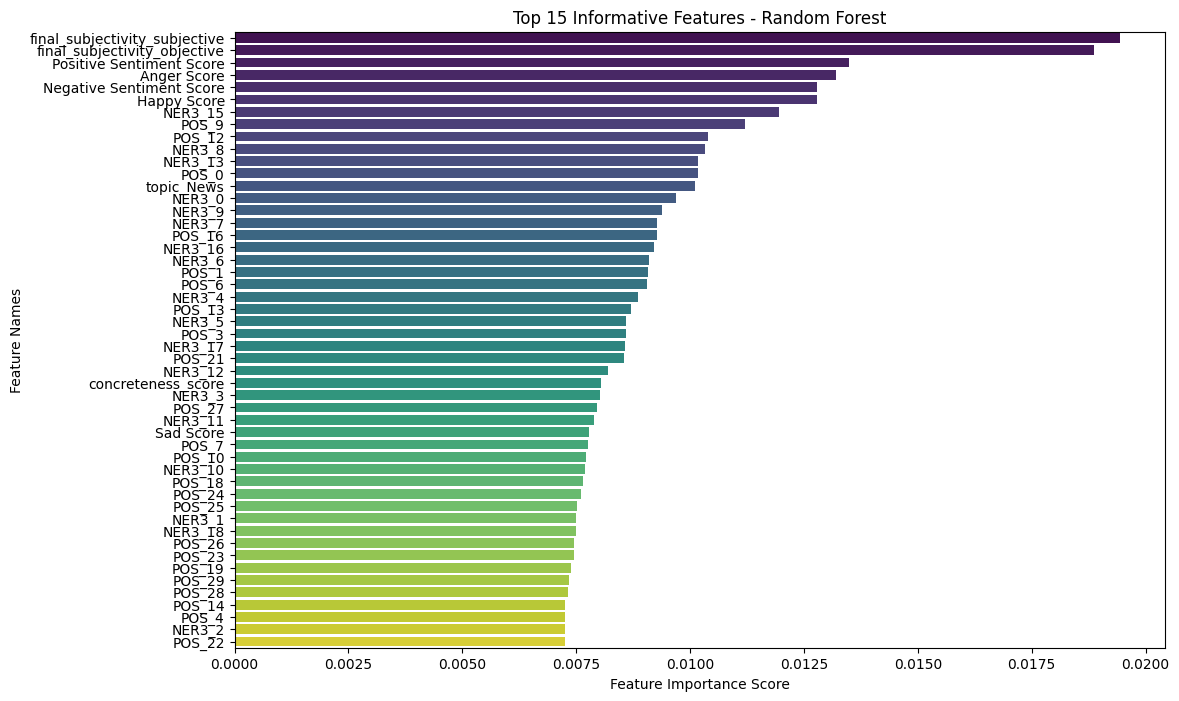

In [ ]:


# Step 1: Select the top 98% of features using SelectKBest with f_classif to preserve most of the relevant information
top_features_percentage = 0.98
n_features = X_train_dev.shape[1]
k = int(n_features * top_features_percentage)
selector = SelectKBest(score_func=f_classif, k=k)
X_selected = selector.fit_transform(X_train_dev, y_train_dev)

# Get selected feature names
selected_feature_names = X_train_dev.columns[selector.get_support()]
X_selected_df = X_train_dev[selected_feature_names]  # Keep only the selected features

# -----------------------
# Random Forest Classifier
# -----------------------

# Step 2a: Train Random Forest Classifier on selected features
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_selected_df, y_train_dev)

# Step 3a: Get feature importances from the Random Forest model
rf_feature_importances = pd.Series(rf_model.feature_importances_, index=selected_feature_names)
rf_sorted_feature_importances = rf_feature_importances.sort_values(ascending=False)

# Step 4a: Visualize Feature Importance for Random Forest
plt.figure(figsize=(12, 8))
sns.barplot(x=rf_sorted_feature_importances[:50], y=rf_sorted_feature_importances.index[:50], palette="viridis")
plt.title("Top 15 Informative Features - Random Forest")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature Names")
plt.show()



**Understanding Feature Importance in Random Forests**

* Random Forests determine feature importance by evaluating how much each feature contributes to reducing the impurity (e.g., Gini impurity or entropy) in decision nodes across all trees in the forest. Features with higher importance scores contribute more to the model’s predictive power and accuracy.

* f_classif (ANOVA F-value) helps determine the best features, particularly for numerical (continuous) features, by analyzing their statistical relationship with the target variable.

* The most important features contribute up to 2% (0.02000) of the overall model importance individually, while features with lower scores contribute much less (near zero).

<ipython-input-68-86dd877251d5>:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=averaged_importances_df['Importance'], y=averaged_importances_df.index, palette="viridis")


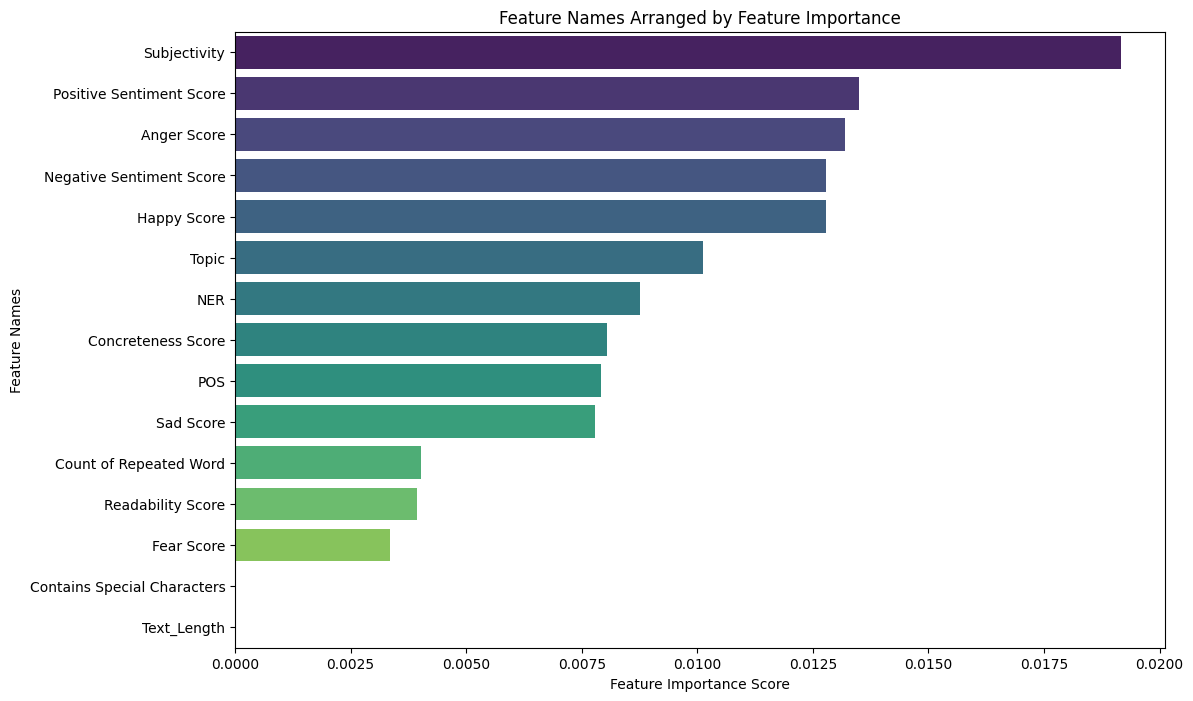

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming `sorted_feature_importances` is a Series with feature importances from the Random Forest model,
# where the index contains expanded feature names like "NER3_0", "POS_1", etc.

# List of original features and their corresponding expanded column prefixes
original_features = {
    'Positive Sentiment Score': ['Positive Sentiment Score'],
    'Negative Sentiment Score': ['Negative Sentiment Score'],
    'Sad Score': ['Sad Score'],
    'Happy Score': ['Happy Score'],
    'Anger Score': ['Anger Score'],
    'Fear Score': ['Fear Score'],
    'Count of Repeated Word': ['Repeated_Word_Count'],
    'Readability Score': ['final_readability_score'],
    'Concreteness Score': ['concreteness_score'],
    'POS': [f'POS_{i}' for i in range(embedding_df_train_dev.filter(like='POS_').shape[1])],  # All POS_* columns
    'NER': [f'NER3_{i}' for i in range(embedding_df_train_dev.filter(like='NER3_').shape[1])],  # All NER3_* columns
    'Subjectivity': ['final_subjectivity_subjective', 'final_subjectivity_objective'],
    'Topic': ['topic_News'],  # Assuming this was one-hot encoded as a single feature
    'Contains Special Characters': ['Contains_Special_Chars'],
    'Text_Length': ['Text_Length']
}

# Calculate average importances by original feature
averaged_importances = {}
for feature, columns in original_features.items():
    # Extract importance scores for all columns that correspond to this feature
    relevant_importances = rf_sorted_feature_importances[rf_sorted_feature_importances.index.isin(columns)]
    # Compute the average importance for this feature
    averaged_importances[feature] = relevant_importances.mean() if not relevant_importances.empty else 0

# Convert to DataFrame for plotting
averaged_importances_df = pd.DataFrame.from_dict(averaged_importances, orient='index', columns=['Importance'])
averaged_importances_df = averaged_importances_df.sort_values(by='Importance', ascending=False)

# Plot averaged feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=averaged_importances_df['Importance'], y=averaged_importances_df.index, palette="viridis")
plt.title("Feature Names Arranged by Feature Importance")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature Names")
plt.show()


## Models

In [ ]:
# Define class weight parameter for XGBClassifier based on class imbalance
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
# Define evaluation function
def evaluate_model_performance(y_true, y_pred):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro',zero_division=1)
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro',zero_division=1)
    acc = accuracy_score(y_true, y_pred)
    return {
        'Accuracy': acc,
        'Macro F1': f1_macro,
        'Micro F1': f1_micro,
    }


In [ ]:
# Initialize models to test
# models = {
#     'RandomForest': RandomForestClassifier(),
#     'SVM': SVC(),
#     'XGBoost': XGBClassifier(),
#     'Perceptron': Perceptron(),
#     'MultinomialNB': MultinomialNB(),          # Multinomial Naive Bayes
#     'DecisionTree': DecisionTreeClassifier() ,   # Decision Tree Classifier
#     'Logistic Regression':LogisticRegression()
#  }




# # Calculate `scale_pos_weight` for XGBClassifier
# unique_classes = np.unique(y_train_dev)
# class_weights = compute_class_weight('balanced', classes=unique_classes, y=y_train_dev)
# scale_pos_weight = class_weights[1] / class_weights[0]  # Adjust weight for XGBoost

# Updated models with balanced class weights
models = {
    'RandomForest': RandomForestClassifier(),
    'SVM': SVC(),  # Add class_weight
    #'XGBoost': XGBClassifier(scale_pos_weight=scale_pos_weight),  # Add scale_pos_weight
    # 'Perceptron': Perceptron(),  # No class_weight, leave as-is
    # 'MultinomialNB': MultinomialNB(),  # No class_weight, leave as-is
    # 'DecisionTree': DecisionTreeClassifier(class_weight='balanced'),  # Add class_weight
    'Logistic Regression': LogisticRegression()  # class_weight='balanced'
}






results = []

# Loop through each model
for model_name, model in models.items():
    # Step 1: Test each model with each individual feature
    for feature in individual_features:


        if feature == "text":
            X_train_feature_set = text_df_train_dev
            X_test_feature_set = text_df_test
        elif feature in numerical_features:
            # Numerical feature selection
            X_train_feature_set = numerical_df_train_dev[[feature]]
            X_test_feature_set = numerical_df_test[[feature]]
        elif feature in embedding_features:
            # Embedding feature selection
            X_train_feature_set = embedding_df_train_dev.filter(regex=f"^{feature}_")
            X_test_feature_set = embedding_df_test.filter(regex=f"^{feature}_")
        # elif feature in categorical_features:
        #     # Categorical feature selection
        #     # feature_cols = categorical_df_train_dev.filter(regex=f"^{feature}_").columns
        #     # X_train_feature_set = categorical_df_train_dev[feature_cols]
        #     # X_test_feature_set = categorical_df_test[feature_cols]
        #           # Directly select the column for label-encoded features
        #       X_train_feature_set = categorical_df_train_dev[[feature]]
        #       X_test_feature_set = categorical_df_test[[feature]]


        # Perform cross-validation
        cv_scores = cross_val_score(model, X_train_feature_set, y_train_dev, cv=5, scoring='f1_weighted')
        mean_cv_f1 = cv_scores.mean()

        # Train on the single feature and evaluate on the test set
        model.fit(X_train_feature_set, y_train_dev)
        y_test_pred = model.predict(X_test_feature_set)
        test_performance = evaluate_model_performance(y_test, y_test_pred)

        # Store the result for this single feature
        results.append({
            'Model': model_name,
            'Feature Set': f"Single Feature: {feature}",
            'CV Weighted F1': mean_cv_f1,
            **test_performance  # Unpack test performance metrics
        })

    # Step 2: Test each model with all features combined
    # text_df_test,
    #text_df_train_dev,
#, categorical_df_train_dev
#, categorical_df_test
    X_train_full_feature_set = pd.concat([text_df_train_dev, numerical_df_train_dev, embedding_df_train_dev], axis=1)
    X_test_full_feature_set = pd.concat([text_df_test,numerical_df_test, embedding_df_test], axis=1)

    # Perform cross-validation on the full feature set
    cv_scores = cross_val_score(model, X_train_full_feature_set, y_train_dev, cv=5, scoring='f1_weighted')
    mean_cv_f1 = cv_scores.mean()

    # Train on the full feature set and evaluate on the test set
    model.fit(X_train_full_feature_set, y_train_dev)
    y_test_pred = model.predict(X_test_full_feature_set)
    test_performance = evaluate_model_performance(y_test, y_test_pred)

    # Store the result for the full feature set
    results.append({
        'Model': model_name,
        'Feature Set': "All Features",
        'CV Weighted F1': mean_cv_f1,
        **test_performance
    })

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results)
print(results_df)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

                  Model                               Feature Set  \
0          RandomForest                      Single Feature: text   
1          RandomForest  Single Feature: Positive Sentiment Score   
2          RandomForest  Single Feature: Negative Sentiment Score   
3          RandomForest                 Single Feature: Sad Score   
4          RandomForest               Single Feature: Happy Score   
5          RandomForest               Single Feature: Anger Score   
6          RandomForest                Single Feature: Fear Score   
7          RandomForest       Single Feature: Repeated_Word_Count   
8          RandomForest   Single Feature: final_readability_score   
9          RandomForest        Single Feature: concreteness_score   
10         RandomForest        Single Feature: final_subjectivity   
11         RandomForest                     Single Feature: topic   
12         RandomForest    Single Feature: Contains_Special_Chars   
13         RandomForest           

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print("Missing values in text_df_train_dev:", text_df_train_dev.isna().sum().sum())
print("Missing values in numerical_df_train_dev:", numerical_df_train_dev.isna().sum().sum())
print("Missing values in embedding_df_train_dev:", embedding_df_train_dev.isna().sum().sum())
#print("Missing values in categorical_df_train_dev:", categorical_df_train_dev.isna().sum().sum())


Missing values in text_df_train_dev: 0
Missing values in numerical_df_train_dev: 0
Missing values in embedding_df_train_dev: 0


In [ ]:
results_df

,Model,Feature Set,CV Weighted F1,Accuracy,Macro F1,Micro F1
0,RandomForest,Single Feature: text,0.675523,0.699849,0.671106,0.699849
1,RandomForest,Single Feature: Positive Sentiment Score,0.612659,0.589744,0.583835,0.589744
2,RandomForest,Single Feature: Negative Sentiment Score,0.597643,0.575415,0.573825,0.575415
3,RandomForest,Single Feature: Sad Score,0.544101,0.563348,0.563336,0.563348
4,RandomForest,Single Feature: Happy Score,0.617721,0.599548,0.595601,0.599548
5,RandomForest,Single Feature: Anger Score,0.576233,0.571644,0.571425,0.571644
6,RandomForest,Single Feature: Fear Score,0.372299,0.438914,0.404216,0.438914
7,RandomForest,Single Feature: Repeated_Word_Count,0.548342,0.527149,0.520769,0.527149
8,RandomForest,Single Feature: final_readability_score,0.583213,0.613876,0.562602,0.613876
9,RandomForest,Single Feature: concreteness_score,0.537017,0.536953,0.508318,0.536953


In [ ]:
# save results_df as excell

results_df.to_excel('NEW_ML_results_SVM_LR_RF_witText5000_OK.xlsx', index=False)

## ML with Text Only

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import Perceptron
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# Initialize models to test with only text features
# models = {
#     # 'RandomForest': RandomForestClassifier(),
#     # 'SVM': SVC(),
#     # 'XGBoost': XGBClassifier(),
#     # 'Perceptron': Perceptron(),
#     # 'MultinomialNB': MultinomialNB(),
#     # 'DecisionTree': DecisionTreeClassifier()
#     'Logistic Regression':LogisticRegression()
# }



# Updated models with balanced class weights
models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),
    'SVM': SVC(class_weight='balanced'),  # Add class_weight
    #'XGBoost': XGBClassifier(scale_pos_weight=scale_pos_weight),  # Add scale_pos_weight
    # 'Perceptron': Perceptron(),  # No class_weight, leave as-is
    # 'MultinomialNB': MultinomialNB(),  # No class_weight, leave as-is
    # 'DecisionTree': DecisionTreeClassifier(class_weight='balanced'),  # Add class_weight
    'Logistic Regression': LogisticRegression(class_weight='balanced')  # Add class_weight
}





# Initialize results storage
results = []

# Use only text features for testing
X_train_text_only = text_df_train_dev
X_test_text_only = text_df_test

# Loop through each model
for model_name, model in models.items():
    # Perform cross-validation on the text-only feature set
    cv_scores = cross_val_score(model, X_train_text_only, y_train_dev, cv=5, scoring='f1_weighted')
    mean_cv_f1 = cv_scores.mean()

    # Train on the text-only feature set and evaluate on the test set
    model.fit(X_train_text_only, y_train_dev)
    y_test_pred = model.predict(X_test_text_only)
    test_performance = evaluate_model_performance(y_test, y_test_pred)

    # Store the result for the text-only feature set
    results.append({
        'Model': model_name,
        'Feature Set': "Text Only",
        'CV Weighted F1': mean_cv_f1,
        **test_performance  # Unpack test performance metrics
    })

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results)
print(results_df)


                 Model Feature Set  CV Weighted F1  Accuracy  Macro F1  \
0         RandomForest   Text Only        0.685839  0.696078  0.674284   
1                  SVM   Text Only        0.681881  0.717949  0.684803   
2  Logistic Regression   Text Only        0.695772  0.712670  0.697278   

   Micro F1  
0  0.696078  
1  0.717949  
2  0.712670  


In [ ]:
results_df.to_excel('ML_results_SVM_LR_RF_textOnly23709.xlsx', index=False)

## Test on single featuers

In [ ]:
# Initialize models to test
models = {
    'RandomForest': RandomForestClassifier(),
    'SVM': SVC(),
    'XGBoost': XGBClassifier(),
    'Perceptron': Perceptron()
 }

# Feature sets to test
feature_sets = {
    "text": text_df_train_dev,  # Only text features (TF-IDF transformed)
    "text_features": pd.concat([text_df_train_dev, numerical_df_train_dev, embedding_df_train_dev, categorical_df_train_dev], axis=1)  # Text + other features
}

# Prepare a DataFrame to store results
results = []

# Loop through each model and feature set combination
for model_name, model in models.items():
    for feature_set_name, X_train_feature_set in feature_sets.items():

        # Define the corresponding test set based on the feature set
        X_test_feature_set = text_df_test if feature_set_name == "text" else pd.concat([text_df_test, numerical_df_test, embedding_df_test, categorical_df_test], axis=1)

        # Cross-validation on train_dev_df with the current feature set
        cv_scores = cross_val_score(model, X_train_feature_set, y_train_dev, cv=5, scoring='f1_weighted')
        mean_cv_f1 = cv_scores.mean()

        # Train on the full train-dev set with the current feature set and evaluate on the test set
        model.fit(X_train_feature_set, y_train_dev)
        y_test_pred = model.predict(X_test_feature_set)
        test_performance = evaluate_model_performance(y_test, y_test_pred)

        # Append results to the list
        results.append({
            'Model': model_name,
            'Feature Set': feature_set_name,
            'CV Weighted F1': mean_cv_f1,
            **test_performance  # Unpack test performance metrics
        })

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results)
print(results_df)

          Model    Feature Set  CV Weighted F1  Accuracy  Macro F1  Micro F1  \
0  RandomForest           text        0.676870  0.685520  0.663805  0.685520   
1  RandomForest  text_features        0.717662  0.744344  0.695516  0.744344   

   Precision (Macro)  Recall (Macro)  Precision (Micro)  Recall (Micro)  
0           0.663738        0.663873           0.685520        0.685520  
1           0.748981        0.686899           0.744344        0.744344  


In [ ]:
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(train_df['paragraph'])

# Sum term frequencies
term_frequencies = np.array(X_tfidf.sum(axis=0)).flatten()
sorted_indices = np.argsort(term_frequencies)[::-1]

# Cumulative sum of term frequencies
cumulative_frequencies = np.cumsum(term_frequencies[sorted_indices])
total_frequency = cumulative_frequencies[-1]

# Find the number of terms needed to cover 90% of the total frequency
num_features_90pct = np.searchsorted(cumulative_frequencies, 0.9 * total_frequency)
print(f"Number of features to cover 90% of term frequency: {num_features_90pct}")


Number of features to cover 90% of term frequency: 23709


## Featuers without TEXT

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# Define the target column and feature sets
target_column = 'LablePropaganda'
text_features = ['paragraph']

# Exclude numerical features
numerical_features = [
    'Positive Sentiment Score', 'Negative Sentiment Score', 'Sad Score',
    'Happy Score', 'Anger Score', 'Fear Score',
    'Repeated_Word_Count', 'final_readability_score',
    'concreteness_score'
]
embedding_features = ['POS', 'NER3']
categorical_features = ['final_subjectivity', 'topic', 'Contains_Special_Chars', 'Text_Length']

# Encode the binary target label
label_encoder = LabelEncoder()
train_df[target_column] = label_encoder.fit_transform(train_df[target_column])
dev_df[target_column] = label_encoder.transform(dev_df[target_column])
test_df[target_column] = label_encoder.transform(test_df[target_column])

# Combine train and dev datasets for cross-validation
train_dev_df = pd.concat([train_df, dev_df], ignore_index=True)

# Step 1: Scale numerical features
scaler = StandardScaler()
numerical_transformed_train_dev = scaler.fit_transform(train_dev_df[numerical_features])
numerical_df_train_dev = pd.DataFrame(numerical_transformed_train_dev, columns=numerical_features)

numerical_transformed_test = scaler.transform(test_df[numerical_features])
numerical_df_test = pd.DataFrame(numerical_transformed_test, columns=numerical_features)

# Step 2: Process embedding features
embedding_dfs_train_dev = []
embedding_dfs_test = []
for feature in embedding_features:
    train_dev_array = np.vstack(train_dev_df[feature].apply(lambda x: np.array(x)).values)
    test_array = np.vstack(test_df[feature].apply(lambda x: np.array(x)).values)

    train_dev_columns = [f"{feature}_{i}" for i in range(train_dev_array.shape[1])]
    test_columns = [f"{feature}_{i}" for i in range(test_array.shape[1])]

    embedding_dfs_train_dev.append(pd.DataFrame(train_dev_array, columns=train_dev_columns))
    embedding_dfs_test.append(pd.DataFrame(test_array, columns=test_columns))

embedding_df_train_dev = pd.concat(embedding_dfs_train_dev, axis=1)
embedding_df_test = pd.concat(embedding_dfs_test, axis=1)

# Step 3: One-hot encode categorical features
onehot_encoder = OneHotEncoder(handle_unknown='ignore')
categorical_transformed_train_dev = onehot_encoder.fit_transform(train_dev_df[categorical_features]).toarray()
categorical_transformed_test = onehot_encoder.transform(test_df[categorical_features]).toarray()

categorical_df_train_dev = pd.DataFrame(categorical_transformed_train_dev, columns=onehot_encoder.get_feature_names_out(categorical_features))
categorical_df_test = pd.DataFrame(categorical_transformed_test, columns=onehot_encoder.get_feature_names_out(categorical_features))

# Combine all features except the text features
X_train_full_feature_set = pd.concat([numerical_df_train_dev, embedding_df_train_dev, categorical_df_train_dev], axis=1)
X_test_full_feature_set = pd.concat([numerical_df_test, embedding_df_test, categorical_df_test], axis=1)
y_train_dev = train_dev_df[target_column]
y_test = test_df[target_column]

# Define evaluation function
def evaluate_model_performance(y_true, y_pred):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=1)
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro', zero_division=1)
    acc = accuracy_score(y_true, y_pred)
    return {
        'Accuracy': acc,
        'Macro F1': f1_macro,
        'Micro F1': f1_micro,
    }

# Calculate `scale_pos_weight` for XGBClassifier if needed
unique_classes = np.unique(y_train_dev)
class_weights = compute_class_weight('balanced', classes=unique_classes, y=y_train_dev)
scale_pos_weight = class_weights[1] / class_weights[0]  # Adjust weight for XGBoost

# Updated models with balanced class weights
models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),
    'SVM': SVC(class_weight='balanced'),
    'Logistic Regression': LogisticRegression(class_weight='balanced')
}

results = []

# Loop through each model
for model_name, model in models.items():
    # Step 1: Test each model with each individual feature
    for feature in numerical_features + embedding_features + categorical_features:
        if feature in numerical_features:
            X_train_feature_set = numerical_df_train_dev[[feature]]
            X_test_feature_set = numerical_df_test[[feature]]
        elif feature in embedding_features:
            X_train_feature_set = embedding_df_train_dev.filter(regex=f"^{feature}_")
            X_test_feature_set = embedding_df_test.filter(regex=f"^{feature}_")
        elif feature in categorical_features:
            feature_cols = categorical_df_train_dev.filter(regex=f"^{feature}_").columns
            X_train_feature_set = categorical_df_train_dev[feature_cols]
            X_test_feature_set = categorical_df_test[feature_cols]

        # Perform cross-validation
        cv_scores = cross_val_score(model, X_train_feature_set, y_train_dev, cv=5, scoring='f1_weighted')
        mean_cv_f1 = cv_scores.mean()

        # Train on the single feature and evaluate on the test set
        model.fit(X_train_feature_set, y_train_dev)
        y_test_pred = model.predict(X_test_feature_set)
        test_performance = evaluate_model_performance(y_test, y_test_pred)

        # Store the result for this single feature
        results.append({
            'Model': model_name,
            'Feature Set': f"Single Feature: {feature}",
            'CV Weighted F1': mean_cv_f1,
            **test_performance
        })

    # Step 2: Test each model with all features combined (excluding text)
    cv_scores = cross_val_score(model, X_train_full_feature_set, y_train_dev, cv=5, scoring='f1_weighted')
    mean_cv_f1 = cv_scores.mean()

    # Train on the full feature set and evaluate on the test set
    model.fit(X_train_full_feature_set, y_train_dev)
    y_test_pred = model.predict(X_test_full_feature_set)
    test_performance = evaluate_model_performance(y_test, y_test_pred)

    # Store the result for the full feature set
    results.append({
        'Model': model_name,
        'Feature Set': "All Features (excluding text)",
        'CV Weighted F1': mean_cv_f1,
        **test_performance
    })

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results)
print(results_df)




/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

                  Model                               Feature Set  \
0          RandomForest  Single Feature: Positive Sentiment Score   
1          RandomForest  Single Feature: Negative Sentiment Score   
2          RandomForest                 Single Feature: Sad Score   
3          RandomForest               Single Feature: Happy Score   
4          RandomForest               Single Feature: Anger Score   
5          RandomForest                Single Feature: Fear Score   
6          RandomForest       Single Feature: Repeated_Word_Count   
7          RandomForest   Single Feature: final_readability_score   
8          RandomForest        Single Feature: concreteness_score   
9          RandomForest                       Single Feature: POS   
10         RandomForest                      Single Feature: NER3   
11         RandomForest        Single Feature: final_subjectivity   
12         RandomForest                     Single Feature: topic   
13         RandomForest    Single 

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
results_df

,Model,Feature Set,CV Weighted F1,Accuracy,Macro F1,Micro F1
0,RandomForest,Single Feature: Positive Sentiment Score,0.618128,0.589744,0.582888,0.589744
1,RandomForest,Single Feature: Negative Sentiment Score,0.597590,0.577677,0.575893,0.577677
2,RandomForest,Single Feature: Sad Score,0.541268,0.549020,0.548917,0.549020
3,RandomForest,Single Feature: Happy Score,0.617978,0.595777,0.592872,0.595777
4,RandomForest,Single Feature: Anger Score,0.577251,0.566365,0.565909,0.566365
5,RandomForest,Single Feature: Fear Score,0.369660,0.439668,0.406605,0.439668
6,RandomForest,Single Feature: Repeated_Word_Count,0.547882,0.533183,0.526373,0.533183
7,RandomForest,Single Feature: final_readability_score,0.583213,0.613876,0.562602,0.613876
8,RandomForest,Single Feature: concreteness_score,0.536749,0.533937,0.505115,0.533937
9,RandomForest,Single Feature: POS,0.610116,0.659125,0.563751,0.659125


In [ ]:
# save results_df as excell

results_df.to_excel("ML_Results_WithoutText_Features.xlsx", index=False)


# Lubna's Note

in this notebook I used different ML to build the baseline.

اللي صاير أنه بعض المميزات خاصه

catogrical

جربت بالبداية استخدم

one-hot encode

بعدين صارت النتائج حقتها طبق الاصل مع اختلاف المودل اللي هم

categorical_features = ['final_subjectivity', 'topic','Contains_Special_Chars','Text_Length']  # Handle both as categorical


جربت ايضا

ordinal

بعدين بس الموضوع تغيرت قيمته والباقي نفسهم

I used also noraml mapping as I did in BERT pre-processing

بس كمان نفس القيم